In [1]:
#step 1 combning the dataset
import pandas as pd
df_train=pd.read_csv("C:\\Users\\sanas\\OneDrive\\Desktop\\SIMULATION\\train.csv")
df_store=pd.read_csv("C:\\Users\\sanas\\OneDrive\\Desktop\\SIMULATION\\store.csv")

C:\Users\sanas\AppData\Local\Temp\ipykernel_18112\2237426621.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train=pd.read_csv("C:\\Users\\sanas\\OneDrive\\Desktop\\SIMULATION\\train.csv")


In [2]:
df_train.head(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1.0,5.0,31-07-2015,5263.0,555.0,1.0,1.0,0,1.0
1,2.0,5.0,31-07-2015,6064.0,625.0,1.0,1.0,0,1.0
2,3.0,5.0,31-07-2015,8314.0,821.0,1.0,1.0,0,1.0
3,4.0,5.0,31-07-2015,13995.0,1498.0,1.0,1.0,0,1.0
4,5.0,5.0,31-07-2015,4822.0,559.0,1.0,1.0,0,1.0


In [3]:
df_store.head(5)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [4]:
df = pd.merge(df_train, df_store, on="Store", how="left")

In [5]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1.0,5.0,31-07-2015,5263.0,555.0,1.0,1.0,0,1.0,c,a,1270.0,9.0,2008.0,0.0,NaN,NaN,NaN
1,2.0,5.0,31-07-2015,6064.0,625.0,1.0,1.0,0,1.0,a,a,570.0,11.0,2007.0,1.0,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3.0,5.0,31-07-2015,8314.0,821.0,1.0,1.0,0,1.0,a,a,14130.0,12.0,2006.0,1.0,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4.0,5.0,31-07-2015,13995.0,1498.0,1.0,1.0,0,1.0,c,c,620.0,9.0,2009.0,0.0,NaN,NaN,NaN
4,5.0,5.0,31-07-2015,4822.0,559.0,1.0,1.0,0,1.0,a,a,29910.0,4.0,2015.0,0.0,NaN,NaN,NaN


In [6]:
df.shape

(1017209, 18)

In [7]:
df.to_csv("merged_simulation_dataset.csv", index=False)

#Data cleaning

In [8]:
##Remove rows where store was closed
df = df[df['Open'] == 1]

In [9]:
df = df.drop('Open', axis=1)


In [10]:
#Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])


C:\Users\sanas\AppData\Local\Temp\ipykernel_18112\4288188633.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [11]:
df.dtypes

Store                               float64
DayOfWeek                           float64
Date                         datetime64[ns]
Sales                               float64
Customers                           float64
Promo                               float64
StateHoliday                         object
SchoolHoliday                       float64
StoreType                            object
Assortment                           object
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                              float64
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                        object
dtype: object

In [12]:
#create time features
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Week'] = df['Date'].dt.isocalendar().week


In [13]:
df = df.drop('Date', axis=1)

In [14]:
df = df.drop(['StateHoliday',
              'SchoolHoliday',
              'PromoInterval',
              'CompetitionOpenSinceMonth',
              'CompetitionOpenSinceYear'], 
             axis=1, errors='ignore')


In [15]:
#Fill missing values in CompetitionDistance with median
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())


In [16]:
#Fill Promo2 and related promo fields (if present)
df['Promo2'] = df['Promo2'].fillna(0)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0)
df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0)

In [17]:
# Reset index (good practice)
df = df.reset_index(drop=True)

In [18]:
df.head()

,Store,DayOfWeek,Sales,Customers,Promo,StoreType,Assortment,CompetitionDistance,Promo2,Promo2SinceWeek,Promo2SinceYear,Month,Year,Week
0,1.0,5.0,5263.0,555.0,1.0,c,a,1270.0,0.0,0.0,0.0,7,2015,31
1,2.0,5.0,6064.0,625.0,1.0,a,a,570.0,1.0,13.0,2010.0,7,2015,31
2,3.0,5.0,8314.0,821.0,1.0,a,a,14130.0,1.0,14.0,2011.0,7,2015,31
3,4.0,5.0,13995.0,1498.0,1.0,c,c,620.0,0.0,0.0,0.0,7,2015,31
4,5.0,5.0,4822.0,559.0,1.0,a,a,29910.0,0.0,0.0,0.0,7,2015,31


In [19]:
df.isnull().sum()

Store                  0
DayOfWeek              0
Sales                  0
Customers              0
Promo                  0
StoreType              0
Assortment             0
CompetitionDistance    0
Promo2                 0
Promo2SinceWeek        0
Promo2SinceYear        0
Month                  0
Year                   0
Week                   0
dtype: int64

In [20]:
df.columns

Index(['Store', 'DayOfWeek', 'Sales', 'Customers', 'Promo', 'StoreType',
       'Assortment', 'CompetitionDistance', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'Month', 'Year', 'Week'],
      dtype='object')

In [21]:
#converting store type and assortment to numeric
df = pd.get_dummies(df, columns=['StoreType', 'Assortment'], drop_first=True)


In [22]:
df.dtypes

Store                  float64
DayOfWeek              float64
Sales                  float64
Customers              float64
Promo                  float64
CompetitionDistance    float64
Promo2                 float64
Promo2SinceWeek        float64
Promo2SinceYear        float64
Month                    int32
Year                     int32
Week                    UInt32
StoreType_b               bool
StoreType_c               bool
StoreType_d               bool
Assortment_b              bool
Assortment_c              bool
dtype: object

In [23]:
#saving the cleaned dataset
df.to_csv("final_simulation_dataset.csv", index=False)


In [24]:
#Feature selection
features = [
    'Promo',
    'DayOfWeek',
    'Month',
    'CompetitionDistance',
    'Promo2',
    'Promo2SinceWeek',
    'Promo2SinceYear',
    'StoreType_b',
    'StoreType_c',
    'StoreType_d',
    'Assortment_b',
    'Assortment_c'
]


In [25]:
target = 'Sales'


In [26]:
#splitting into train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df[features], df[target], test_size=0.2, random_state=42
)


In [27]:
#using random forest model to predict sales
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
# 1) Model evaluation 
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.3f}")


RMSE: 1405.81
R2:   0.796


In [ ]:
#scenario 1 - no promo

In [29]:
# Scenario 1: No Promotion
scenario_1 = df.copy()
scenario_1['Promo'] = 0

In [30]:
#Predict sales for Scenario 1
X_s1 = scenario_1[X_train.columns]
scenario_1['Predicted_Sales'] = model.predict(X_s1)


In [31]:
#Get total predicted sales (VERY important)
total_sales_s1 = scenario_1['Predicted_Sales'].sum()
total_sales_s1


np.float64(4994988029.598081)

In [ ]:
#scenario 2 - there is prome

In [32]:
# Scenario 2: Regular Promotion (as-is)
scenario_2 = df.copy()

In [33]:
#Predict sales for Scenario 2
X_s2 = scenario_2[X_train.columns]
scenario_2['Predicted_Sales'] = model.predict(X_s2)


In [34]:
#Get total predicted sales
total_sales_s2 = scenario_2['Predicted_Sales'].sum()
total_sales_s2

np.float64(5873804616.045584)

In [36]:
baseline_sales = total_sales_s1


In [37]:
#compute the uplift (ONE small calculation)
uplift_absolute = total_sales_s2 - baseline_sales
uplift_percentage = (uplift_absolute / baseline_sales) * 100

uplift_absolute, uplift_percentage


(np.float64(878816586.4475031), np.float64(17.593967818141433))

In [ ]:
#scenario 3 we assume stronger promotion


In [38]:
scenario_3 = df.copy()
scenario_3['Promo'] = 1

In [39]:
#Predict sales under this condition
X_s3 = scenario_3[X_train.columns]
scenario_3['Predicted_Sales'] = model.predict(X_s3)


In [40]:
#Simulate “stronger” promotion effect
#We now apply a promotion intensity boost.
#We assume:
#Strong promo → 15% higher impact than regular promo
strong_promo_factor = 1.15
scenario_3['Predicted_Sales_Strong'] = scenario_3['Predicted_Sales'] * strong_promo_factor


In [41]:
#Get total predicted sales for Scenario 3
total_sales_s3 = scenario_3['Predicted_Sales_Strong'].sum()
total_sales_s3


np.float64(7904751251.969835)

In [42]:
#Compare Scenario 3 vs Scenario 2
uplift_s3_vs_s2 = total_sales_s3 - total_sales_s2
uplift_pct_s3_vs_s2 = (uplift_s3_vs_s2 / total_sales_s2) * 100

uplift_s3_vs_s2, uplift_pct_s3_vs_s2


(np.float64(2030946635.9242516), np.float64(34.57633967558737))

In [43]:
#Scenario 4 (selective promotion)
# Scenario 4: Selective Promotion (Weekends only)
scenario_4 = df.copy()

# Set promo only for weekends
scenario_4['Promo'] = 0
scenario_4.loc[scenario_4['DayOfWeek'].isin([6, 7]), 'Promo'] = 1


In [44]:
#Predict sales for Scenario 4
X_s4 = scenario_4[X_train.columns]
scenario_4['Predicted_Sales'] = model.predict(X_s4)


In [45]:
#et total predicted sales
total_sales_s4 = scenario_4['Predicted_Sales'].sum()
total_sales_s4


np.float64(5268562421.043108)

In [46]:
#Compare Scenario 4 vs No Promotion
uplift_s4_vs_s1 = total_sales_s4 - baseline_sales
uplift_pct_s4_vs_s1 = (uplift_s4_vs_s1 / baseline_sales) * 100

uplift_s4_vs_s1, uplift_pct_s4_vs_s1


(np.float64(273574391.44502735), np.float64(5.476977919145091))

In [47]:
#Final comparison table
import pandas as pd

final_comparison = pd.DataFrame({
    "Scenario": [
        "No Promotion",
        "Regular Promotion",
        "Strong Promotion",
        "Selective Promotion (Weekends)"
    ],
    "Total Predicted Sales": [
        baseline_sales,
        total_sales_s2,
        total_sales_s3,
        total_sales_s4
    ]
})

# Calculate uplift vs No Promotion
final_comparison["Uplift vs No Promotion"] = (
    final_comparison["Total Predicted Sales"] - baseline_sales
)

final_comparison["% Change vs No Promotion"] = (
    final_comparison["Uplift vs No Promotion"] / baseline_sales * 100
)

final_comparison


,Scenario,Total Predicted Sales,Uplift vs No Promotion,% Change vs No Promotion
0,No Promotion,4.994988e+09,0.000000e+00,0.000000
1,Regular Promotion,5.873805e+09,8.788166e+08,17.593968
2,Strong Promotion,7.904751e+09,2.909763e+09,58.253658
3,Selective Promotion (Weekends),5.268562e+09,2.735744e+08,5.476978


In [ ]:
#Store-Type–Based Promotion — Scenario 5
#“What if promotions are applied only to certain store types?”
#This is a policy-level simulation, not customer segmentation.

In [48]:
#STEP 1: Create the scenario dataset
# Scenario 5: Store-type–based promotion
scenario_5 = df.copy()

# Default: no promotion
scenario_5['Promo'] = 0

# Apply promotion only to selected store types
scenario_5.loc[
    (scenario_5['StoreType_b'] == True) |
    (scenario_5['StoreType_c'] == True) |
    (scenario_5['StoreType_d'] == True),
    'Promo'
] = 1


In [49]:
#STEP 2: Predict sales for Scenario 5
# Predict sales for store-type–based promotion scenario
X_s5 = scenario_5[X_train.columns]
scenario_5['Predicted_Sales'] = model.predict(X_s5)


In [50]:
#STEP 3: Get total predicted sales
total_sales_s5 = scenario_5['Predicted_Sales'].sum()
total_sales_s5


np.float64(5831590691.049246)

In [52]:
#Scenario 5 vs Regular Promotion
uplift_s5_vs_s2 = total_sales_s5 - total_sales_s2
uplift_pct_s5_vs_s2 = (uplift_s5_vs_s2 / total_sales_s2) * 100

uplift_s5_vs_s2, uplift_pct_s5_vs_s2


(np.float64(-42213924.99633789), np.float64(-0.718681123322034))

In [ ]:
#Reduced Promotion — Scenario 6
#What if the company reduces the number of promotion days?
#This tests efficiency, not aggressiveness:
#Are promotions being overused?
#Can we save cost with minimal loss in sales?

In [53]:
#Create Reduced Promotion dataset
# Scenario 6: Reduced Promotion (50% of promo days)
scenario_6 = df.copy()

# Find all rows where promotion is currently on
promo_days = scenario_6[scenario_6['Promo'] == 1].index

# Randomly select 50% of those promo days
reduced_promo_days = promo_days.to_series().sample(
    frac=0.5, random_state=42
).index

# Turn OFF promo for the remaining 50%
scenario_6.loc[promo_days.difference(reduced_promo_days), 'Promo'] = 0


In [54]:
#Predict sales for Reduced Promotion
# Predict sales for reduced promotion scenario
X_s6 = scenario_6[X_train.columns]
scenario_6['Predicted_Sales'] = model.predict(X_s6)


In [55]:
#Get total predicted sales
total_sales_s6 = scenario_6['Predicted_Sales'].sum()
total_sales_s6

np.float64(5434285495.916434)

In [56]:
#Reduced vs Regular Promotion
uplift_s6_vs_s2 = total_sales_s6 - total_sales_s2
uplift_pct_s6_vs_s2 = (uplift_s6_vs_s2 / total_sales_s2) * 100

uplift_s6_vs_s2, uplift_pct_s6_vs_s2


(np.float64(-439519120.12914944), np.float64(-7.482699014681331))

In [ ]:
#Assortment-Based Promotion — Scenario 7
#What if promotions are applied only to stores with larger product assortments?”
#Stores with extra or extended assortment respond better to promotions.
#Basic assortment stores get no promotion.

In [57]:
#Scenario 7 dataset
# Scenario 7: Assortment-based promotion
scenario_7 = df.copy()

# Default: no promotion
scenario_7['Promo'] = 0

# Apply promotion only to stores with larger assortments
scenario_7.loc[
    (scenario_7['Assortment_b'] == True) |
    (scenario_7['Assortment_c'] == True),
    'Promo'
] = 1


In [58]:
# Predict sales for assortment-based promotion scenario
X_s7 = scenario_7[X_train.columns]
scenario_7['Predicted_Sales'] = model.predict(X_s7)


In [59]:
total_sales_s7 = scenario_7['Predicted_Sales'].sum()
total_sales_s7


np.float64(5871996758.412681)

In [60]:
uplift_s7_vs_s2 = total_sales_s7 - total_sales_s2
uplift_pct_s7_vs_s2 = (uplift_s7_vs_s2 / total_sales_s2) * 100

uplift_s7_vs_s2, uplift_pct_s7_vs_s2


(np.float64(-1807857.632903099), np.float64(-0.03077830726552497))

In [61]:
#Final table of all scenarios
import pandas as pd

final_table = pd.DataFrame({
    "Scenario": [
        "No Promotion",
        "Regular Promotion",
        "Strong Promotion",
        "Selective Promotion (Weekends)",
        "Store-Type–Based Promotion",
        "Reduced Promotion (50%)",
        "Assortment-Based Promotion"
    ],
    "Total Predicted Sales": [
        baseline_sales,
        total_sales_s2,
        total_sales_s3,
        total_sales_s4,
        total_sales_s5,
        total_sales_s6,
        total_sales_s7
    ]
})

# Uplift compared to No Promotion
final_table["Uplift vs No Promotion"] = (
    final_table["Total Predicted Sales"] - baseline_sales
)

final_table["% Change vs No Promotion"] = (
    final_table["Uplift vs No Promotion"] / baseline_sales * 100
)

final_table


,Scenario,Total Predicted Sales,Uplift vs No Promotion,% Change vs No Promotion
0,No Promotion,4.994988e+09,0.000000e+00,0.000000
1,Regular Promotion,5.873805e+09,8.788166e+08,17.593968
2,Strong Promotion,7.904751e+09,2.909763e+09,58.253658
3,Selective Promotion (Weekends),5.268562e+09,2.735744e+08,5.476978
4,Store-Type–Based Promotion,5.831591e+09,8.366027e+08,16.748842
5,Reduced Promotion (50%),5.434285e+09,4.392975e+08,8.794765
6,Assortment-Based Promotion,5.871997e+09,8.770087e+08,17.557774


In [24]:
#Demand-Based Segmentation
#We will cluster store-days based on demand patterns (sales & footfall), not customers.
#we use sales, customers and promo
from sklearn.preprocessing import StandardScaler

# Select demand-related features
segmentation_features = df[['Sales', 'Customers', 'Promo']]

# Scale features (VERY important for K-Means)
scaler = StandardScaler()
segmentation_scaled = scaler.fit_transform(segmentation_features)


In [25]:
from sklearn.cluster import KMeans

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(segmentation_scaled)

# Add cluster labels to the dataframe
df['Demand_Segment'] = clusters


In [26]:
df['Demand_Segment'].value_counts()


Demand_Segment
1    435912
0    322920
2     85542
Name: count, dtype: int64

In [27]:
# Understand each demand segment
df.groupby('Demand_Segment')[['Sales', 'Customers', 'Promo']].mean()


,Sales,Customers,Promo
Demand_Segment,,,
0,7297.685674,727.775836,1.000000
1,5456.580170,621.793720,0.000000
2,13302.497697,1612.789530,0.630988


In [27]:
df.head()
df.columns

Index(['Store', 'DayOfWeek', 'Sales', 'Customers', 'Promo',
       'CompetitionDistance', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear',
       'Month', 'Year', 'Week', 'StoreType_b', 'StoreType_c', 'StoreType_d',
       'Assortment_b', 'Assortment_c'],
      dtype='object')

EDA

In [28]:
df.groupby('Promo')[['Sales','Customers']].mean()

,Sales,Customers
Promo,,
0.0,5929.420005,696.841372
1.0,8228.281239,844.434401


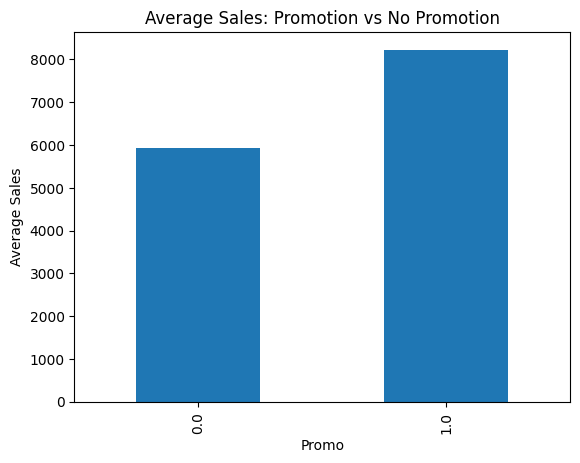

In [29]:
import matplotlib.pyplot as plt

df.groupby('Promo')['Sales'].mean().plot(kind='bar')
plt.title("Average Sales: Promotion vs No Promotion")
plt.ylabel("Average Sales")
plt.show()

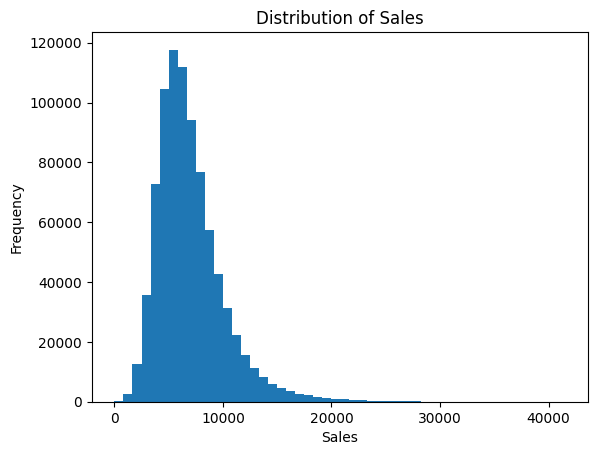

In [30]:
plt.hist(df['Sales'], bins=50)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

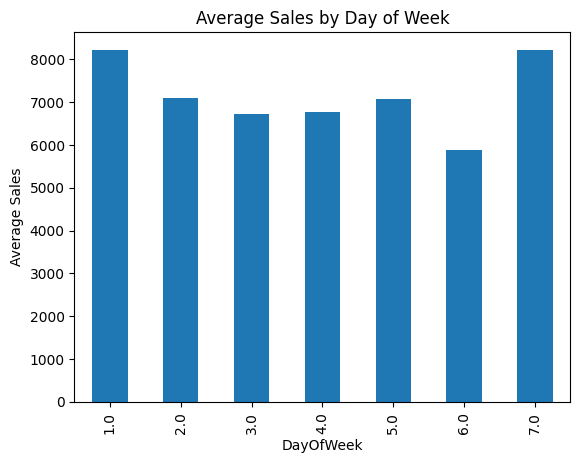

In [31]:
df.groupby('DayOfWeek')['Sales'].mean().plot(kind='bar')
plt.title("Average Sales by Day of Week")
plt.ylabel("Average Sales")
plt.show()

In [33]:
def get_store_type(row):
    if row['StoreType_b']:
        return 'B'
    elif row['StoreType_c']:
        return 'C'
    elif row['StoreType_d']:
        return 'D'
    else:
        return 'A'

df['StoreType_Label'] = df.apply(get_store_type, axis=1)

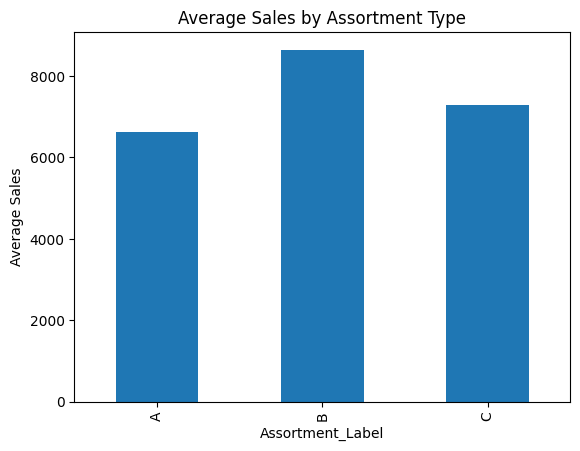

In [34]:
def get_assortment(row):
    if row['Assortment_b']:
        return 'B'
    elif row['Assortment_c']:
        return 'C'
    else:
        return 'A'

df['Assortment_Label'] = df.apply(get_assortment, axis=1)

df.groupby('Assortment_Label')['Sales'].mean().plot(kind='bar')
plt.title("Average Sales by Assortment Type")
plt.ylabel("Average Sales")
plt.show()

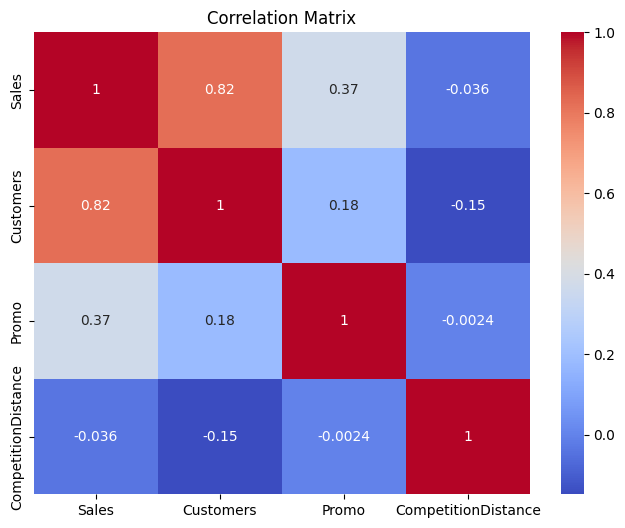

In [35]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df[['Sales','Customers','Promo','CompetitionDistance']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [36]:
from scipy.stats import ttest_ind

# Separate sales into two groups
sales_promo = df[df['Promo'] == 1]['Sales']
sales_no_promo = df[df['Promo'] == 0]['Sales']

# Perform independent t-test
t_stat, p_value = ttest_ind(sales_promo, sales_no_promo, equal_var=False)

t_stat, p_value

(np.float64(356.63384025431367), np.float64(0.0))